# Human Immune Health Atlas: sample representation benchmark

Blood immune single-cell data from the Dynamics of Immune Health and Age study (Nature 2025, [PMID 41162704](https://pubmed.ncbi.nlm.nih.gov/41162704/)). Donors vary in age and CMV status; cells are annotated with Allen Institute AIFI labels at several resolutions.

Download `human_immune_health_atlas_full.h5ad` from the Immune Health Atlas catalog:
https://apps.allenimmunology.org/aifi/resources/imm-health-atlas/downloads/scrna/

Direct link to the full object (on the order of 40 GB):
https://allenimmunology.org/public/publication/download/84792154-cdfb-42d0-8e42-39e210e980b4/filesets/568ad40c-516a-4646-9426-bdcd7029c1f5/human_immune_health_atlas_full.h5ad


## CLR composition

`CellGroupComposition(apply_clr=True)` builds per-sample cell type proportions and applies a centered log-ratio (CLR) so distances are not driven only by total abundance. The other methods in the benchmark use the same label column but aggregate cells in different ways.


## Install patpy


In [1]:
!pip install git+https://github.com/lueckenlab/patpy.git@main


  Cloning https://github.com/lueckenlab/patpy.git (to revision main) to /private/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/pip-req-build-bhm5x3nu
  Running command git clone --filter=blob:none --quiet https://github.com/lueckenlab/patpy.git /private/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/pip-req-build-bhm5x3nu
  Resolved https://github.com/lueckenlab/patpy.git to commit 270d75cd34cb1382c66823df68c6e7f054341e70
  Running command git submodule update --init --recursive -q
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


  Created wheel for patpy: filename=patpy-0.16.2-py3-none-any.whl size=95935 sha256=c01eb6c054fe87b23147027e287ed86658d3a78e3fa8517eb5ac9e70b5fb2285
  Stored in directory: /private/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/pip-ephem-wheel-cache-gunokmof/wheels/1f/f2/21/441ac370cbf51632fe4a586014f18d78b0ffb350ccaaf55226
Successfully built patpy
  Attempting uninstall: patpy
    Found existing installation: patpy 0.11.2
    Uninstalling patpy-0.11.2:
      Successfully uninstalled patpy-0.11.2

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## Import packages


In [2]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns

import patpy

warnings.filterwarnings("ignore", category=UserWarning)


## Read the data

Set `ADATA_PATH` to your local `human_immune_health_atlas_full.h5ad`. The object should have `obsm['X_pca']` (used by pseudobulk-style methods).


In [3]:
ADATA_PATH = "/Users/kylekimler/Projects/patient-maps-playground/data/human_immune_health_atlas_full.h5ad"


In [4]:
adata = sc.read_h5ad(ADATA_PATH)
adata


AnnData object with n_obs × n_vars = 1821725 × 1236
    obs: 'cohort.cohortGuid', 'sample.sampleKitGuid', 'specimen.specimenGuid', 'pipeline.fileGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.birthYear', 'subject.ageAtFirstDraw', 'subject.ageGroup', 'subject.race', 'subject.ethnicity', 'subject.cmv', 'subject.bmi', 'sample.visitName', 'sample.drawYear', 'sample.subjectAgeAtDraw', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'barcodes', 'original_barcodes', 'cell_name', 'n_reads', 'n_umis', 'n_genes', 'total_counts_mito', 'pct_counts_mito', 'doublet_score', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3'
    var: 'mito', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'AIFI_L1_colors', 'AIFI_L2_colors', 'AIFI_L3_colors', 'celltypist.low_colors', 'hvg', 'keep_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'seurat.

## Benchmark

For each AIFI resolution (L1–L3) and each method, build sample distances and score them with KNN against a biological **relevant** block (age at first draw, age group, sex, ethnicity, CMV, BMI) and a **technical** block (batch-style IDs). Race, birth year, and per-cell QC fields are excluded. For technical targets, scores are inverted so that **higher always means better** (strong biology in the geometry; weak batch leakage), matching `patpy.tl.evaluation.knn_prediction_score`.

This loop reuses the same `adata`; if you hit odd state, restart from a fresh `read_h5ad`.


In [5]:
SAMPLE_KEY = "sample.sampleKitGuid"
LABEL_RESOLUTIONS = ["AIFI_L1", "AIFI_L2", "AIFI_L3"]
# Columns used only for UMAP coloring below
AGE_COL = "subject.ageAtFirstDraw"
CMV_COL = "subject.cmv"
RNG = 67
N_NEIGHBORS = 7

# KNN tasks per covariate; "relevant" = biological, "technical" = batch / processing
BENCHMARK_SCHEMA = {
    "relevant": {
        "subject.ageAtFirstDraw": "regression",
        "subject.ageGroup": "classification",
        "subject.biologicalSex": "classification",
        "subject.ethnicity": "classification",
        "subject.cmv": "classification",
        "subject.bmi": "regression",
    },
    "technical": {
        "batch_id": "classification",
        "pool_id": "classification",
        "chip_id": "classification",
        "well_id": "classification",
        "sample.drawYear": "regression",
    },
}

REQ_OBS = (
    {SAMPLE_KEY, CMV_COL, AGE_COL, *LABEL_RESOLUTIONS}
    | {c for bucket in BENCHMARK_SCHEMA.values() for c in bucket}
)

for col in REQ_OBS:
    assert col in adata.obs, col
assert "X_pca" in adata.obsm, "need X_pca in obsm for pseudobulk methods"


def build_method(method: str, label_key: str):
    if method == "composition_clr":
        return patpy.tl.CellGroupComposition(SAMPLE_KEY, label_key, apply_clr=True, seed=RNG)
    if method == "pseudobulk":
        return patpy.tl.Pseudobulk(SAMPLE_KEY, label_key, layer="X_pca", seed=RNG)
    if method == "grouped_pseudobulk":
        return patpy.tl.GroupedPseudobulk(SAMPLE_KEY, label_key, layer="X_pca", seed=RNG)
    if method == "random_baseline":
        return patpy.tl.RandomVector(SAMPLE_KEY, label_key, latent_dim=32, seed=RNG)
    raise ValueError(method)


METHOD_ORDER = ["composition_clr", "pseudobulk", "grouped_pseudobulk", "random_baseline"]

rows: list[dict] = []
for label_key in LABEL_RESOLUTIONS:
    for method in METHOD_ORDER:
        m = build_method(method, label_key)
        m.prepare_anndata(adata)
        force = method.startswith("composition")
        m.calculate_distance_matrix(force=force)
        for covariate_type, cov_map in BENCHMARK_SCHEMA.items():
            for cov_col, task in cov_map.items():
                out = m.evaluate_representation(
                    cov_col, method="knn", n_neighbors=N_NEIGHBORS, task=task
                )
                rows.append(
                    {
                        "label_key": label_key,
                        "method": method,
                        "covariate": cov_col,
                        "covariate_type": covariate_type,
                        "task": task,
                        "score": out["score"],
                        "metric": out["metric"],
                    }
                )

benchmark_long = pd.DataFrame(rows)


def _plot_score(row: pd.Series) -> float:
    s = float(row["score"])
    if row["covariate_type"] == "technical":
        s = 1.0 - s
    if row["metric"] == "spearman_r":
        s = abs(s)
    return s


benchmark_long["plot_score"] = benchmark_long.apply(_plot_score, axis=1)

bio = benchmark_long[benchmark_long["covariate_type"] == "relevant"]
tech = benchmark_long[benchmark_long["covariate_type"] == "technical"]
summary = (
    bio.groupby(["label_key", "method"], as_index=False)["plot_score"]
    .mean()
    .rename(columns={"plot_score": "bio_mean"})
    .merge(
        tech.groupby(["label_key", "method"], as_index=False)["plot_score"]
        .mean()
        .rename(columns={"plot_score": "tech_mean"}),
        on=["label_key", "method"],
        how="outer",
    )
)
summary["mean_score"] = (summary["bio_mean"] + summary["tech_mean"]) / 2.0
results = summary.sort_values("mean_score", ascending=False).reset_index(drop=True)

# SPARE-style dot plot: one strip per covariate type; x = method × resolution; y = normalized score
benchmark_long["method_resolution"] = (
    benchmark_long["method"].str.replace("_", " ") + " | " + benchmark_long["label_key"]
)
order_x = [
    f"{m.replace('_', ' ')} | {lbl}" for m in METHOD_ORDER for lbl in LABEL_RESOLUTIONS
]

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharey=True)
for ax, ctype, title in zip(
    axes,
    ["relevant", "technical"],
    ["Biological (relevant)", "Technical (batch; higher = less predictable)"],
    strict=True,
):
    sub = benchmark_long[benchmark_long["covariate_type"] == ctype]
    sns.stripplot(
        data=sub,
        x="method_resolution",
        y="plot_score",
        hue="covariate",
        order=order_x,
        dodge=True,
        jitter=0.25,
        alpha=0.85,
        size=6,
        ax=ax,
    )
    ax.axhline(0.5, color="0.7", lw=0.8, ls="--")
    ax.set_xlabel("")
    ax.set_ylabel("Score (↑ better)")
    ax.set_title(title)
    ax.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right")

fig.suptitle("Sample-representation benchmark: KNN on donor × donor distances", y=1.02)
fig.tight_layout()
plt.show()

results


,label_key,method,age_score,age_metric,cmv_score,cmv_metric,mean_score
0,AIFI_L3,composition_clr,0.810606,spearman_r,0.784763,f1_macro_calibrated,0.797684
1,AIFI_L1,pseudobulk,0.538058,spearman_r,0.354289,f1_macro_calibrated,0.446174
2,AIFI_L3,pseudobulk,0.538058,spearman_r,0.354289,f1_macro_calibrated,0.446174
3,AIFI_L3,grouped_pseudobulk,0.650529,spearman_r,0.218881,f1_macro_calibrated,0.434705
4,AIFI_L1,grouped_pseudobulk,0.471060,spearman_r,0.109043,f1_macro_calibrated,0.290051
5,AIFI_L1,composition_clr,0.352763,spearman_r,0.000000,f1_macro_calibrated,0.176381
6,AIFI_L3,random_baseline,0.305901,spearman_r,0.036415,f1_macro_calibrated,0.171158
7,AIFI_L1,random_baseline,0.000000,spearman_r,0.000000,f1_macro_calibrated,0.000000


## UMAP on distances for top runs

Refit the two highest `mean_score` rows and plot UMAP on the distance matrix colored by age and CMV.


/Users/kylekimler/miniforge3/envs/patpy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


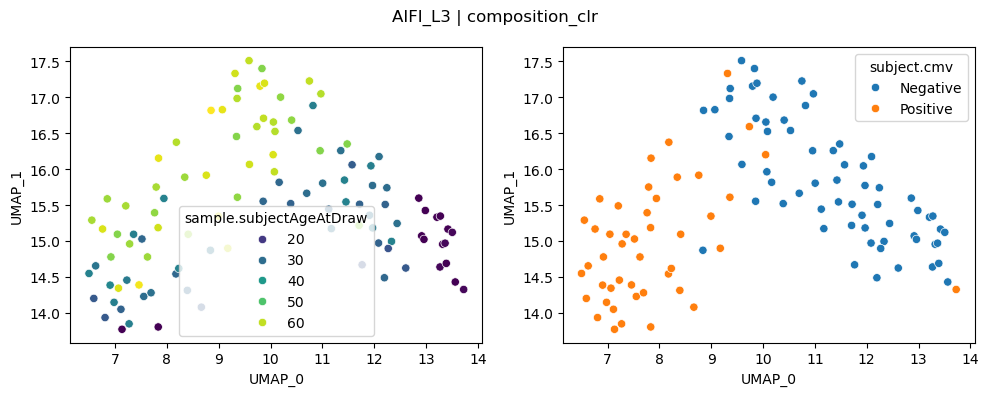

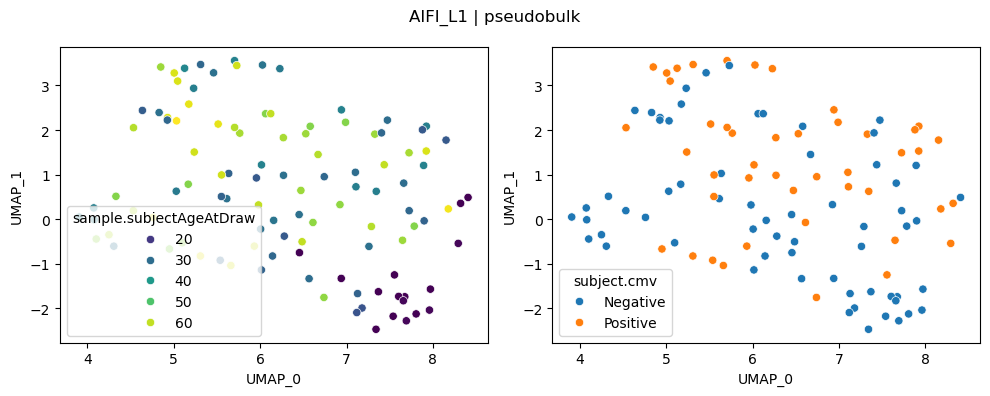

In [6]:
top2 = results.sort_values("mean_score", ascending=False).head(2)
for _, row in top2.iterrows():
    label_key = row["label_key"]
    method = row["method"]
    m = build_method(method, label_key)
    m.prepare_anndata(adata)
    m.calculate_distance_matrix(force=method.startswith("composition"))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    m.plot_embedding(method="UMAP", metadata_cols=[AGE_COL, CMV_COL], axes=axes)
    fig.suptitle(f"{label_key} | {method}")
    plt.tight_layout()


## Results

Compare `mean_score` (average of per-target scores after the same normalization as the SPARE-style benchmark) across rows. High **bio_mean** means donor metadata is easy to read from neighbor geometry; high **tech_mean** means batch IDs are hard to predict (better confounder control). The random baseline should be weak on biology if the pipeline is behaving.
